## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





In [1]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random as rd

In [ ]:
# Step 1: funzione che simula N lanci (0 = croce, 1 = testa) e restituisce la percentuale che esca testa
def simulazione_lanci(N):
    lanci = [np.random.randint(0,2) for i in range(N)]
    return (sum(lanci)/N)*100

print("Percentuale che esca testa: ", simulazione_lanci(90))

Percentuale che esca testa:  45.55555555555556


In [16]:
# Funzione che restituisce il numero di volte che esce testa dandole la percenutale che esca testa (vec_prob)
def funzione (vec_prob, n):
    p_testa = vec_prob / 100                                                            # converto la percentuale in probabilità
    campione = np.random.choice(a=[0,1], size=n, replace=True, p=[1-p_testa, p_testa])  # devo fare una lista per p perchè per testa e croce ho una lista
    return sum(campione)

print("Numero di volte che esce testa data la percentuale: ", funzione(45.55555, 90))

Numero di volte che esce testa data la percentuale:  35


In [ ]:
# Step 2: numero di lanci e percentuale
def simulazione_lanci(N):
    lanci = [rd.randint(0,1) for i in range(N)]
    return (sum(lanci)/N)*100

campioni =[ n for n in range(10,20001, int(20000/100))]                             # crea una lista, parte da 10 fino a 2000 con passo 200
risultati_campioni = [simulazione_lanci(n) for n in campioni]                       # simula i lanci e salva le percentuali di teste in una lista
ls_risultati = [[campioni[i],risultati_campioni[i]] for i in range(len(campioni))]  # lista che combina i due risultati
df = pd.DataFrame(ls_risultati)

print("Lista con nr lanci e perc teste: ", ls_risultati)

Lista con nr lanci e perc teste:  [[10, 70.0], [210, 50.476190476190474], [410, 49.02439024390244], [610, 50.98360655737705], [810, 50.864197530864196], [1010, 51.18811881188119], [1210, 51.570247933884296], [1410, 48.79432624113475], [1610, 51.11801242236025], [1810, 51.270718232044196], [2010, 50.64676616915423], [2210, 50.542986425339365], [2410, 49.08713692946058], [2610, 49.57854406130268], [2810, 49.46619217081851], [3010, 49.86710963455149], [3210, 50.68535825545172], [3410, 49.03225806451613], [3610, 49.80609418282548], [3810, 50.78740157480315], [4010, 50.02493765586035], [4210, 49.80997624703088], [4410, 50.45351473922902], [4610, 50.62906724511931], [4810, 50.145530145530145], [5010, 50.7185628742515], [5210, 50.05758157389635], [5410, 51.090573012939004], [5610, 49.233511586452764], [5810, 49.53528399311532], [6010, 50.29950083194675], [6210, 50.51529790660225], [6410, 49.17316692667706], [6610, 49.98487140695915], [6810, 49.60352422907489], [7010, 49.74322396576319], [7210

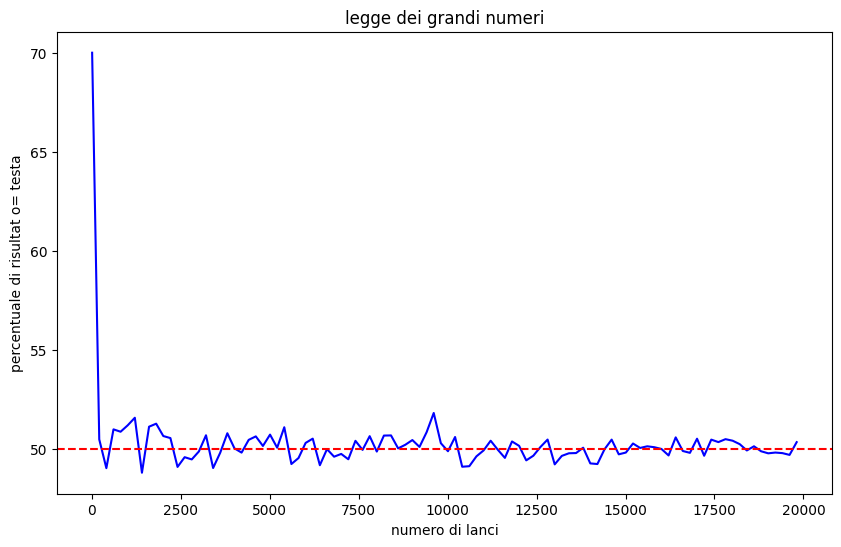

In [22]:
# Step 3: plot della percentuale di teste(y) al variare del numero di lanci(x)
plt.figure(figsize = (10,6))                                   # creo il grafico con queste dimensioni
sns.lineplot(data = df, x = df[0], y = df[1], color = "blue")  # linea blu: colonna 0 (nr lanci) sull'asse x, colonna 1 sull'asse y (perc lanci)
plt.axhline(50, color = 'red', linestyle = '--')               # a quota 50 disegna una linea tratteggiata
plt.xlabel("numero di lanci")
plt.ylabel("percentuale di risultat o= testa")
plt.title("legge dei grandi numeri")
plt.show()

# riga rossa trateggiata è la media

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [23]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [32]:
# Step 1: quante righe e colonne ha il dataset
righe = df.iloc[0]
colonne = len(df.columns)

print("Numero di righe: ", righe)
print("Numero di colonne: ", colonne)

Numero di righe:  PassengerId                          1
Survived                             0
Pclass                               3
Name           Braund, Mr. Owen Harris
Sex                               male
Age                               22.0
SibSp                                1
Parch                                0
Ticket                       A/5 21171
Fare                              7.25
Cabin                              NaN
Embarked                             S
Name: 0, dtype: object
Numero di colonne:  12


In [34]:
# Step 2: calcola quanti valori mancanti per colonna
mancanti = df.isnull().sum()

print("Valori mancanti: ", mancanti)

Valori mancanti:  PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
# Step 3: Riempire valori mancanti della colonna Embarked con il valore più frequente
df_drop = df.dropna()                              # tolgo i valori mancanti
piu_freq = df_drop['Embarked'].mode()[0]           # prende il primo valore più frequente
df['Embarked'] = df['Embarked'].fillna(piu_freq)   # mette il valore più frequente dove ci sono NaN

print("Valore più frequente: ", piu_freq)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [41]:
# Step 4: cntrolla se ci sono righe duplicete
nr_righe_dup = df.duplicated().sum()

print("Numero righe duplicete: ", nr_righe_dup)

Numero righe duplicete:  0


In [45]:
# Step 5: calcolare età media dei passeggeri per ogni classe (Pclass)
# se ci sono valori mancanti di età nella colonna Age riempili con il valore medio
df_pulito = df.dropna()                           # tolgo i dati mancanti
med_eta = df_pulito['Age'].mean()                 # calcolo la media senza dati mancanti
df['Age'] = df['Age'].fillna(med_eta)             # inserisco l'età media li dove mancano valori
eta_media = df.groupby('Pclass')['Age'].mean()    # calcolo media raggruppata per Pclass

print("Età media per ogni calsse (Pclass): ", eta_media)

Età media per ogni calsse (Pclass):  Pclass
1    37.899532
2    30.233436
3    28.101231
Name: Age, dtype: float64


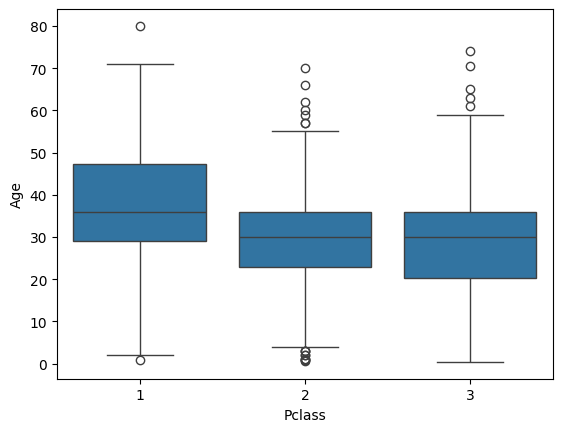

In [46]:
# Step 6: visualizzare la distribuzione dell'età per classe
sns.boxplot(data = df, x = 'Pclass', y = 'Age')
plt.show()

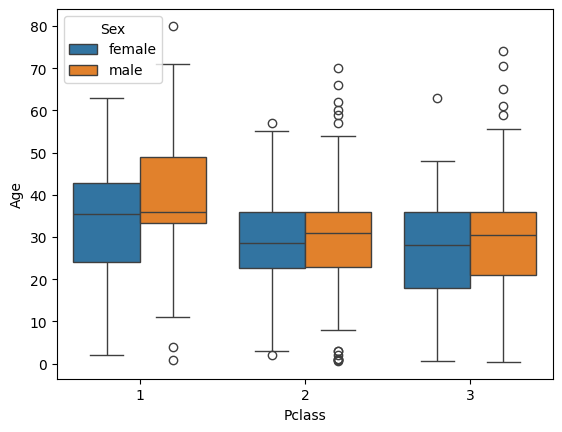

In [49]:
# Step 7: visualizzare la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne
sns.boxplot(data = df, x = 'Pclass', y = 'Age', hue = 'Sex')
plt.show()

## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [51]:
# Step 1: esplorare la distribuzione delle specie (contare quanti campioni ci sono per specie)
campioni_specie = df['species'].value_counts()

print("Numero di campioni per specie: ", campioni_specie)

Numero di campioni per specie:  species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [ ]:
# Step 2: calcolare la lunghezza e la larghezza media dei petali per specie

In [ ]:
# Step 3: visualizzare le dimensioni dei petali per specie (scatterplot)

In [ ]:
# Step 4: creare una nuova colonna per l'area del petalo e analizzala

In [ ]:
# Step 5: grafico della distribuzione dell'area del petalo per specie (boxplot)